# 02 — Model comparison

Section 5 (Modelling and Diagnostics) of the Cross-Sectional Alpha Ranking project.

1. Dataset: processed features and labels at rebalance dates
2. Hyperparameters, chosen on the validation window only
3. Final walk-forward runs: validate (2023) and test (2024), reported separately
4. Rank IC by month
5. In-sample vs. out-of-sample
6. Coefficients and feature importances
7. Are the models just rediscovering size or beta?
8. Save predictions for the backtest

Every model is retrained at each rebalance date on rows whose label is already known (`label_end <= date`). The test window is run once, with parameters fixed from the validation window.

In [1]:
import sys
from pathlib import Path

sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from data import load
from features import FEATURES, build_features
from labels import make_labels, rebalance_dates
from models import (
    ic_summary,
    make_dataset,
    oos_accuracy,
    oos_r2,
    rank_ic,
    walk_forward_predict,
)
from preprocess import preprocess

pd.set_option("display.precision", 3)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
BLUE, GRAY = "#2a6fdb", "#8c9099"

FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", dpi=150)

## 1. Dataset

In [2]:
px = load()
rb = rebalance_dates(px["date"].unique())
labels = make_labels(px, rb)
feats = preprocess(build_features(px))

data = make_dataset(feats[feats.index.get_level_values("date").isin(rb)], labels)
data = data[data.index.get_level_values("date") >= "2015-01-01"]
label_end = data["label_end"].groupby(level="date").first()

WINDOWS = {"validate": ("2023-01-01", "2023-12-31"), "test": ("2024-01-01", "2024-12-31")}
print(data.shape, "rows;", label_end.index.min().date(), "to", label_end.index.max().date())
print("labelled rebalance dates per window:",
      {w: int(((label_end.index >= a) & (label_end.index <= b)).sum()) for w, (a, b) in WINDOWS.items()})

c:\Users\Eklavya\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(10114, 11) rows; 2015-01-30 to 2024-11-29
labelled rebalance dates per window: {'validate': 12, 'test': 11}


In [3]:
def run(name, window, **params):
    return walk_forward_predict(data, FEATURES, label_end, name, *WINDOWS[window], **params)

## 2. Hyperparameters (validation window only)

Each candidate is run through the 2023 walk-forward and scored by mean rank IC. The test window is not touched here. With about 12 monthly ICs the choice is noisy, so prefer the simpler setting when scores are close.

In [4]:
GRIDS = {
    "ridge": [{"alpha": a} for a in [0.1, 1, 10, 100, 1e3, 1e4]],
    "logit": [{"C": c} for c in [1e-4, 1e-3, 1e-2, 1e-1, 1]],
    "rf": [{"max_depth": dep, "min_samples_leaf": leaf} for dep in (2, 3, 4) for leaf in (50, 100)],
}

results = {name: [] for name in GRIDS}
for name, grid in GRIDS.items():
    for params in grid:
        pred, _ = run(name, "validate", **params)
        results[name].append((params, ic_summary(rank_ic(pred))))

tuning = pd.DataFrame([{"model": n, **p, **s} for n, res in results.items() for p, s in res])
BEST = {name: max(res, key=lambda r: r[1]["mean_ic"])[0] for name, res in results.items()}
print("selected:", BEST)
tuning[["model", "alpha", "C", "max_depth", "min_samples_leaf", "mean_ic", "ic_ir", "hit_rate"]]

selected: {'ridge': {'alpha': 0.1}, 'logit': {'C': 1}, 'rf': {'max_depth': 4, 'min_samples_leaf': 100}}


,model,alpha,C,max_depth,min_samples_leaf,mean_ic,ic_ir,hit_rate
0,ridge,0.1,NaN,NaN,NaN,0.092,0.406,0.750
1,ridge,1.0,NaN,NaN,NaN,0.092,0.406,0.750
2,ridge,10.0,NaN,NaN,NaN,0.092,0.404,0.750
3,ridge,100.0,NaN,NaN,NaN,0.090,0.395,0.750
4,ridge,1000.0,NaN,NaN,NaN,0.085,0.358,0.750
5,ridge,10000.0,NaN,NaN,NaN,0.079,0.335,0.583
6,logit,NaN,1.000e-04,NaN,NaN,0.026,0.149,0.417
7,logit,NaN,1.000e-03,NaN,NaN,0.043,0.212,0.583
8,logit,NaN,1.000e-02,NaN,NaN,0.068,0.336,0.750
9,logit,NaN,1.000e-01,NaN,NaN,0.081,0.408,0.750


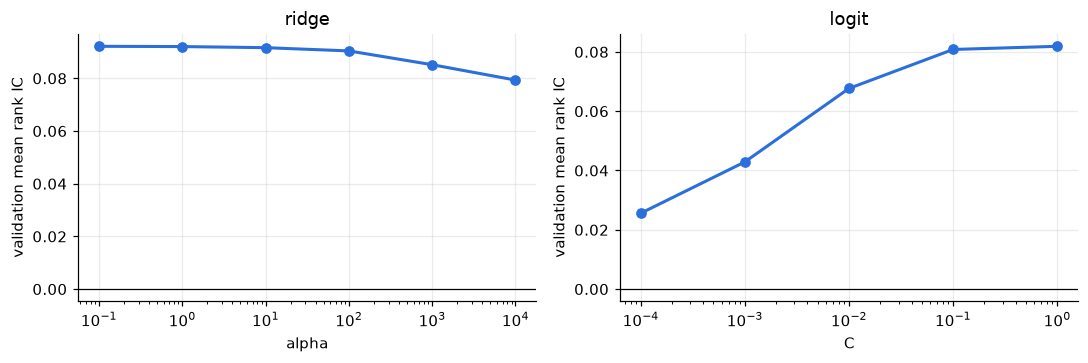

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, name, key in ((axes[0], "ridge", "alpha"), (axes[1], "logit", "C")):
    t = tuning[tuning["model"] == name]
    ax.plot(t[key], t["mean_ic"], marker="o", color=BLUE, lw=2)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xscale("log")
    ax.set_xlabel(key)
    ax.set_ylabel("validation mean rank IC")
    ax.set_title(name)
save(fig, "tuning_validation")

## 3. Final walk-forward runs

In [6]:
OUT = {}
for name in GRIDS:
    for window in WINDOWS:
        OUT[(name, window)] = run(name, window, **BEST[name])

METRIC = {"ridge": "R2", "logit": "accuracy", "rf": "accuracy"}


def summarize(pred, log, name):
    s = ic_summary(rank_ic(pred))
    s["metric"] = METRIC[name]
    s["in_sample"] = log["train_score"].mean()
    s["out_of_sample"] = oos_r2(pred) if name == "ridge" else oos_accuracy(pred)
    return s


summary = pd.DataFrame({k: summarize(p, l, k[0]) for k, (p, l) in OUT.items()}).T
summary.index.names = ["model", "window"]
summary

c:\Users\Eklavya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Eklavya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Eklavya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\U

mean_ic std_ic  ic_ir t_stat hit_rate n_dates    metric  \
model window                                                             
ridge validate   0.092  0.227  0.406  1.407     0.75      12        R2   
      test      -0.033  0.172  -0.19  -0.63    0.273      11        R2   
logit validate   0.082  0.199  0.412  1.426     0.75      12  accuracy   
      test      -0.038  0.162 -0.237 -0.785    0.364      11  accuracy   
rf    validate    0.07  0.158   0.44  1.525    0.667      12  accuracy   
      test      -0.046  0.175 -0.261 -0.864    0.455      11  accuracy   

               in_sample out_of_sample  
model window                            
ridge validate     0.003         0.009  
      test         0.004        -0.012  
logit validate     0.524         0.536  
      test         0.521         0.488  
rf    validate      0.56         0.521  
      test         0.558         0.485

Rank IC is the Spearman correlation, per rebalance date, between the model's score and the realised forward return. The target is a small, stable, positive IC across 2024. The `hit_rate` column is the share of months with a positive IC.

## 4. Rank IC by month

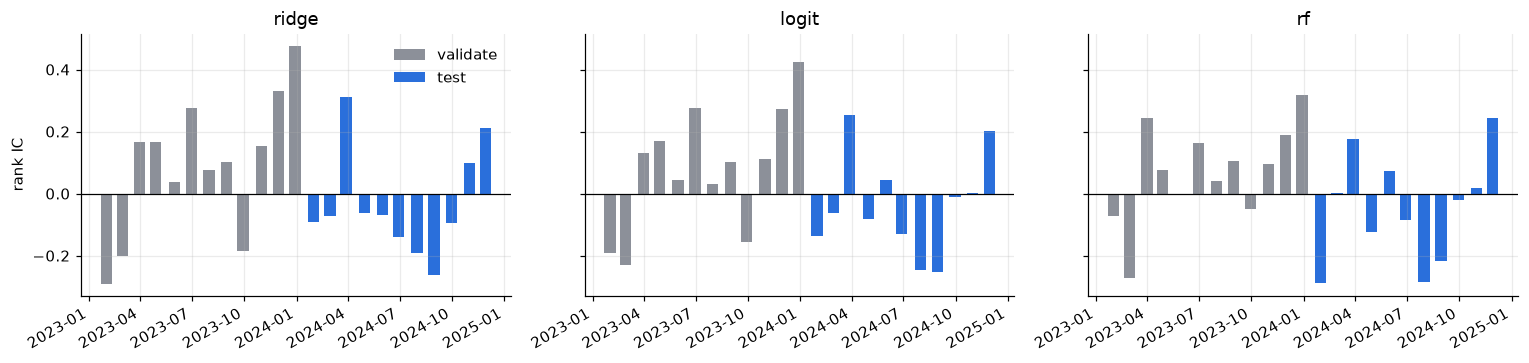

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, name in zip(axes, GRIDS):
    for window, color in (("validate", GRAY), ("test", BLUE)):
        ic = rank_ic(OUT[(name, window)][0])
        ax.bar(ic.index, ic.values, width=20, color=color, label=window)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(name)
axes[0].set_ylabel("rank IC")
axes[0].legend(frameon=False)
fig.autofmt_xdate()
save(fig, "monthly_rank_ic")

## 5. In-sample vs. out-of-sample

In [8]:
summary[["metric", "in_sample", "out_of_sample"]]

metric in_sample out_of_sample
model window                                    
ridge validate        R2     0.003         0.009
      test            R2     0.004        -0.012
logit validate  accuracy     0.524         0.536
      test      accuracy     0.521         0.488
rf    validate  accuracy      0.56         0.521
      test      accuracy     0.558         0.485

**To note for the report:** R² for Ridge and accuracy for the classifiers, averaged over retrains for the in-sample column. The gap between the two columns is the overfitting. Expect it to be largest for the Random Forest and smallest for strongly regularised Ridge. Monthly return prediction is a low-signal problem, so out-of-sample R² near zero or slightly negative and accuracy near 0.5 are normal, and the rank IC is the more meaningful number.

## 6. Coefficients and feature importances

ridge         logit            rf       
            mean    std   mean    std   mean    std
ret_5      0.002  0.008  0.011  0.014  0.167  0.008
ret_20     0.056  0.011  0.107  0.018  0.115  0.009
ret_60     0.071  0.005  0.135  0.010  0.158  0.009
vol_20     0.017  0.007  0.010  0.010  0.121  0.014
relvol_20 -0.013  0.003 -0.021  0.005  0.131  0.017
rsi_14    -0.067  0.016 -0.168  0.030  0.159  0.011
macd_norm -0.055  0.008 -0.085  0.021  0.149  0.012

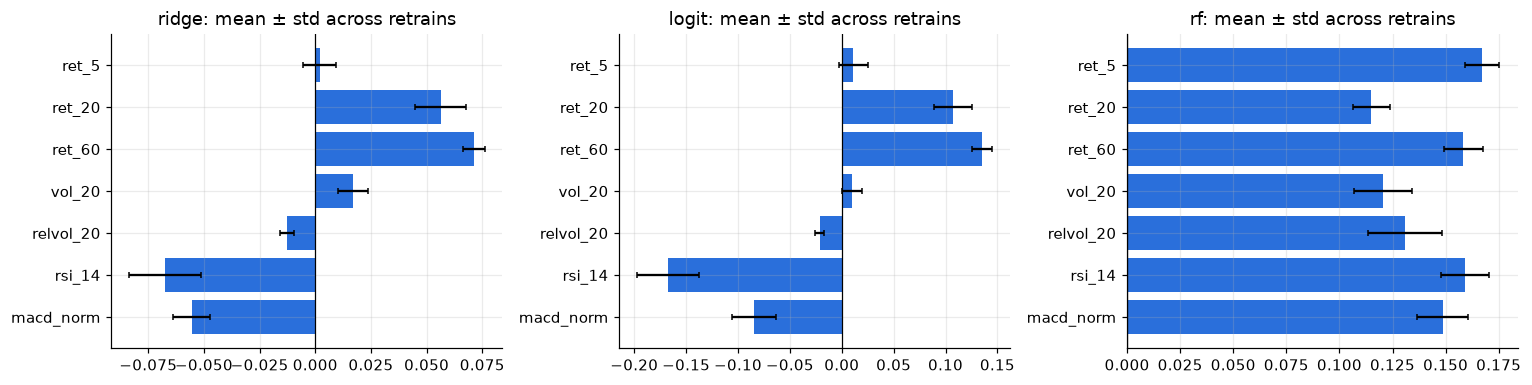

In [9]:
imp_cols = [f"imp_{c}" for c in FEATURES]
imp = {}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, name in zip(axes, GRIDS):
    log = pd.concat([OUT[(name, w)][1] for w in WINDOWS])
    m, s = log[imp_cols].mean(), log[imp_cols].std()
    imp[name] = pd.DataFrame({"mean": m.values, "std": s.values}, index=FEATURES)
    ax.barh(FEATURES, m.values, xerr=s.values, color=BLUE, capsize=2)
    ax.axvline(0, color="black", lw=0.8)
    ax.invert_yaxis()
    ax.set_title(f"{name}: mean ± std across retrains")
save(fig, "coefficients_importances")
pd.concat(imp, axis=1)

Ridge and Logistic show signed coefficients on z-scored features. The Random Forest shows unsigned importances. Large standard deviations across retrains mean an unstable relationship; the correlated features (`ret_20`, `rsi_14`, `macd_norm`) can split or swap credit between retrains.

## 7. Are the models rediscovering size or beta?

OHLCV has no market cap, so size is proxied by log average dollar volume over 60 days, and beta by the trailing 126-day beta against the equal-weighted universe return. Both use data up to the rebalance date only.

In [10]:
close_w = px.pivot(index="date", columns="ticker", values="close")
vol_w = px.pivot(index="date", columns="ticker", values="volume")
ret_w = np.log(close_w).diff()
mkt = ret_w.mean(axis=1)
beta_w = ret_w.rolling(126, min_periods=60).cov(mkt).div(mkt.rolling(126, min_periods=60).var(), axis=0)
size_w = np.log((close_w * vol_w).rolling(60, min_periods=60).mean())


def to_long(w, name):
    out = w.reset_index().melt(id_vars="date", var_name="ticker", value_name=name)
    return out.set_index(["date", "ticker"])[name]


proxies = pd.concat([to_long(beta_w, "beta"), to_long(size_w, "size")], axis=1)


def mean_rank_corr(df, a, b):
    return pd.Series({d: spearmanr(g[a], g[b])[0] for d, g in df.groupby(level="date")}).mean()


corr_rows, ic_rows = {}, {}
for name in GRIDS:
    pred = pd.concat([OUT[(name, w)][0] for w in WINDOWS])
    j = pred.join(proxies, how="left").dropna(subset=["beta", "size"])
    corr_rows[name] = {p: mean_rank_corr(j, "score", p) for p in ("beta", "size")}

any_pred = pd.concat([OUT[("ridge", w)][0] for w in WINDOWS])
for p in ("beta", "size"):
    tmp = proxies[[p]].join(any_pred[["fwd_ret"]], how="inner").dropna().rename(columns={p: "score"})
    ic_rows[p] = ic_summary(rank_ic(tmp))

print("Mean cross-sectional rank correlation between model score and proxy (validate + test):")
display(pd.DataFrame(corr_rows).T)
print("Rank IC of the proxies themselves as scores:")
display(pd.DataFrame(ic_rows).T)

Mean cross-sectional rank correlation between model score and proxy (validate + test):


,beta,size
ridge,0.288,0.089
logit,0.189,0.092
rf,0.141,0.092


Rank IC of the proxies themselves as scores:


,mean_ic,std_ic,ic_ir,t_stat,hit_rate,n_dates
beta,0.055,0.309,0.177,0.850,0.609,23.0
size,-0.048,0.115,-0.413,-1.978,0.478,23.0


**To note for the report:** a score with a large rank correlation to beta or size, and a proxy with an IC of similar size to the model's, suggests the model is mostly a beta or size bet. Low correlations support the claim that the signal is something else.

## 8. Save predictions for the backtest

In [11]:
frames = [pred.assign(model=name, window=w) for (name, w), (pred, _) in OUT.items()]
preds_all = pd.concat(frames)
preds_all.to_parquet("../data/predictions.parquet")
preds_all.groupby(["model", "window"]).size().unstack()

window,test,validate
model,,
logit,1001,1092
rf,1001,1092
ridge,1001,1092
